# Visualizing Data with Pandas

Visualization is a powerful tool for exploring and understanding data. In this notebook, you'll learn how to create various types of plots using pandas and matplotlib to visualize a **fitness dataset** (activity_level, age_group, weekly_workouts, avg_daily_steps, sleep_hours, water_liters, resting_heart_rate, vo2_estimate, fitness_level). You'll discover how different visualization techniques can reveal patterns, distributions, and relationships in your data.

## Objectives

- Load the dataset into pandas
- Create bar charts to visualize categorical data
- Create histograms to explore the distribution of numerical data
- Create box plots to compare distributions across categories

In [1]:
# ============================================================
# Student exercise: Import libraries and load the dataset
#
# ============================================================
# Step: import pandas library as pd
import pandas as pd
# Path handles file paths consistently across operating systems
from pathlib import Path

# Step: set the path to the csv file
# (synthetic dataset in the Demos folder)
data_path = Path('../starter/synthetic_data.csv')

# Step: load the data into a pandas DataFrame using read_csv()
df = pd.read_csv(data_path)


### Visualize activity level distribution
Create a bar chart to visualize the count of individuals by activity level. This will help you understand which activity levels are most common in the dataset.

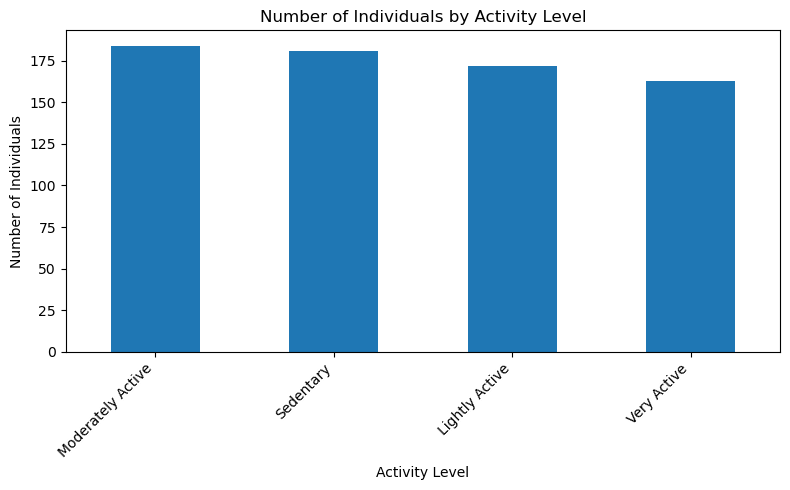

In [2]:
# ============================================================
# Student exercise: Bar chart of activity level distribution
#
# Instruction:
# Create a bar chart showing the count of individuals by activity_level using matplotlib.
# Be sure to add a title and label the axes.
# ============================================================
# Step: import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Step: use value_counts() to count occurrences of each activity level, then plot as a bar chart
df['activity_level'].value_counts().plot(kind='bar', figsize=(8, 5))

# Step: add title and axis labels
plt.title('Number of Individuals by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Number of Individuals')

# Step: rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Step: adjust layout and display the plot
plt.tight_layout()
plt.show()


### Visualize age group distribution
Create a bar chart to visualize the count of individuals by age group. This will show you the distribution of individuals across different age groups.

In [3]:
# ============================================================
# Student exercise: Bar chart of age group distribution
#
# Instruction:
# Create a bar chart showing the count of individuals by age_group using hvplot.
# Be sure to add a title and label the axes.
# ============================================================
# Step: import hvplot.pandas
import hvplot.pandas

# Count occurrences
counts = df['age_group'].value_counts()

# Convert to percentages
percentages = counts / counts.sum() * 100

# DataFrame
perc_df = percentages.reset_index()
perc_df.columns = ['age_group', 'percentage']

# Step: create an interactive bar chart using hvplot with title and axis labels
perc_df.hvplot.bar(x='age_group', y='percentage',
                     title='Number of Individuals by Age Group',
                     xlabel='Age Group',
                     ylabel='Percentage of Individuals',
                     width=800, height=500).opts(xrotation=45)


:Bars   [age_group]   (percentage)

### Visualize the distribution of VO2 estimate
Create a histogram to explore the distribution of vo2_estimate, which represents cardiovascular fitness levels. This helps you understand the fitness distribution in the dataset.

In [4]:
# ============================================================
# Student exercise: Histogram of VO2 estimate
#
# Instruction:
# Create a histogram of the vo2_estimate column using hvplot.
# This shows the distribution of cardiovascular fitness levels.
# Be sure to add a title and label the axes.
# ============================================================
# Step: import hvplot.pandas
import hvplot.pandas

# Step: create an interactive histogram using hvplot.hist()
# The bins parameter controls the number of intervals in the histogram
df.hvplot.hist(y='vo2_estimate', bins=25,
               title='Distribution of VO2 Estimate',
               xlabel='VO2 Estimate',
               width=800, height=500)


:Histogram   [vo2_estimate]   (Count)

### Compare VO2 estimate by age group
Create a box plot to compare the distribution of VO2 estimates across different age groups. This visualization helps identify patterns in fitness levels across different age groups.

In [5]:
# ============================================================
# Student exercise: Box plot comparing VO2 estimate by age group
#
# Instruction:
# Create a box plot comparing vo2_estimate across different age groups using hvplot.
# Be sure to add a title and label the axes.
# ============================================================
# Step: import hvplot.pandas
import hvplot.pandas

# Step: create an interactive box plot using hvplot.box()
# The 'by' parameter groups the data by age_group
df.hvplot.box(y='vo2_estimate', by='age_group',
                     title='VO2 Estimate by Age Group',
                     xlabel='Age Group',
                     ylabel='VO2 Estimate',
                     width=800, height=500)
                     


:BoxWhisker   [age_group]   (vo2_estimate)

### Compare average VO2 estimate across activity levels using a line plot
Create a line plot to visualize how the average VO2 estimate varies across different activity levels. Line plots are useful for showing trends and comparing values across categories in a continuous manner.

In [6]:
# Calculate the mean VO2 estimate per activity level
avg_vo2 = (
    df.groupby('activity_level')['vo2_estimate']
      .mean()
      .sort_values()
)

# Create line plot with hvPlot
avg_vo2.hvplot.line(
    title='Average VO2 Estimate by Activity Level',
    xlabel='Activity Level',
    ylabel='Average VO2 Estimate',
    width=600,
    height=400
)



:Curve   [activity_level]   (vo2_estimate)

### Explore relationships between numerical variables using a scatter plot
Create a scatter plot to visualize the relationship between two numerical variables. Scatter plots are excellent for identifying correlations, trends, and outliers in the data. This helps you understand how different features relate to each other.

In [7]:
# ============================================================
# Student exercise: Scatter plot of weekly workouts vs VO2 estimate
#
# Instruction:
# Create a scatter plot comparing weekly_workouts and vo2_estimate using hvplot.
# Scatter plots help identify relationships and patterns between two numerical variables.
# Be sure to add a title and label the axes.
# ============================================================
# Step: import hvplot.pandas
import hvplot.pandas

# Step: prepare the data by selecting relevant columns and removing missing values
subset = df[['weekly_workouts', 'vo2_estimate']].dropna()

# Step: create an interactive scatter plot using hvplot with title and axis labels
subset.hvplot.scatter(x='weekly_workouts', y='vo2_estimate',
                      title='Weekly Workouts vs VO2 Estimate',
                      xlabel='Weekly Workouts (sessions per week)',
                      ylabel='VO2 Estimate',
                      width=800, height=500)


:Scatter   [weekly_workouts]   (vo2_estimate)

### Visualize correlations between numerical variables using a heatmap
Create a correlation heatmap to visualize the strength and direction of relationships between numerical variables. Correlation values range from -1 to 1, where values close to 1 indicate strong positive correlation, values close to -1 indicate strong negative correlation, and values near 0 indicate weak or no correlation.

In [11]:
# ============================================================
# Student exercise: Correlation heatmap of numerical variables
#
# Instruction:
# Create a correlation heatmap for numerical features using pandas.
# Be sure to add a title and label the axes.
# ============================================================
# Step: identify numerical columns for correlation analysis
cols = ['weekly_workouts', 'avg_daily_steps', 'sleep_hours', 'water_liters', 'resting_heart_rate', 'vo2_estimate']


# Step: compute the correlation matrix
corr = df[cols].corr()

# Step: create the heatmap using pandas style.background_gradient()
# cmap='coolwarm' uses a color scheme, vmin and vmax set the color scale range
# The background_gradient method applies a color gradient to the DataFrame cells
corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).set_caption("Correlation Matrix (Pearson)")

,weekly_workouts,avg_daily_steps,sleep_hours,water_liters,resting_heart_rate,vo2_estimate
weekly_workouts,1.000000,0.306705,0.027231,0.010890,-0.506889,0.475101
avg_daily_steps,0.306705,1.000000,0.046081,0.064995,-0.159466,0.578609
sleep_hours,0.027231,0.046081,1.000000,0.042874,-0.167299,0.021068
water_liters,0.010890,0.064995,0.042874,1.000000,-0.066089,0.010926
resting_heart_rate,-0.506889,-0.159466,-0.167299,-0.066089,1.000000,-0.213418
vo2_estimate,0.475101,0.578609,0.021068,0.010926,-0.213418,1.000000


### Explore relationships between three variables using a 3D scatter plot
Create a 3D scatter plot to visualize relationships between three numerical variables simultaneously. This allows you to understand complex relationships that might not be apparent in 2D plots. Here we explore how weekly workouts, sleep hours, and VO2 estimates relate to each other, colored by activity level.

In [9]:
# ============================================================
# Student exercise: 3D scatter plot of weekly workouts vs sleep hours vs VO2 estimate
#
# Instruction:
# Create an interactive 3D scatter plot using Plotly to visualize relationships between weekly_workouts, 
# sleep_hours, and vo2_estimate, colored by activity_level.
# Plotly allows you to interact with the plot - zoom, pan, and rotate in 3D space.
# Be sure to add a title and label the axes.
# ============================================================
# Step: import plotly.express as px
import plotly.express as px

# Step: prepare the data by selecting relevant columns and removing missing values
subset = df[['weekly_workouts', 'sleep_hours', 'vo2_estimate', 'activity_level']].dropna()

# Step: create the interactive 3D scatter plot with title and axis labels
fig = px.scatter_3d(subset, x='weekly_workouts', y='sleep_hours', z='vo2_estimate',
                    color='activity_level',
                    labels={'weekly_workouts': 'Weekly Workouts', 'sleep_hours': 'Sleep Hours', 'vo2_estimate': 'VO2 Estimate'},
                    title='Weekly Workouts, Sleep Hours, and VO2 Estimate by Activity Level')

# Step: adjust marker size for better visibility
fig.update_traces(marker=dict(size=4))

# Step: display the interactive plot
fig.show()
